In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATASET_DIR = r"C:\PlantVillage-Dataset\raw\color"

print("Dataset path:")
print(DATASET_DIR)

print("\nDataset exists:", os.path.exists(DATASET_DIR))

Dataset path:
C:\PlantVillage-Dataset\raw\color

Dataset exists: True


In [3]:
classes = sorted([
    folder
    for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Number of classes:", len(classes))

print("\nClasses:")
for i, cls in enumerate(classes):
    print(i, "->", cls)

Number of classes: 38

Classes:
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy
5 -> Cherry_(including_sour)___Powdery_mildew
6 -> Cherry_(including_sour)___healthy
7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 -> Corn_(maize)___Common_rust_
9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blight
31 -> T

In [4]:
data = []

for label, class_name in enumerate(classes):

    class_path = os.path.join(DATASET_DIR, class_name)

    for filename in os.listdir(class_path):

        if filename.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(class_path, filename)

            # Separate crop and disease
            parts = class_name.split("___")

            crop = parts[0]
            disease = parts[1] if len(parts) > 1 else "Unknown"

            data.append({
                "image_path": image_path,
                "crop": crop,
                "disease": disease,
                "label": label
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["label"].nunique())

df.head()

Total images: 54305
Total classes: 38


,image_path,crop,disease,label
0,C:\PlantVillage-Dataset\raw\color\Apple___Appl...,Apple,Apple_scab,0
1,C:\PlantVillage-Dataset\raw\color\Apple___Appl...,Apple,Apple_scab,0
2,C:\PlantVillage-Dataset\raw\color\Apple___Appl...,Apple,Apple_scab,0
3,C:\PlantVillage-Dataset\raw\color\Apple___Appl...,Apple,Apple_scab,0
4,C:\PlantVillage-Dataset\raw\color\Apple___Appl...,Apple,Apple_scab,0


In [5]:
class_counts = df["disease"].value_counts()

print(class_counts)

disease
healthy                                 15084
Haunglongbing_(Citrus_greening)          5507
Bacterial_spot                           5421
Tomato_Yellow_Leaf_Curl_Virus            5357
Late_blight                              2909
Powdery_mildew                           2887
Early_blight                             2000
Black_rot                                1801
Septoria_leaf_spot                       1771
Spider_mites Two-spotted_spider_mite     1676
Target_Spot                              1404
Esca_(Black_Measles)                     1383
Common_rust_                             1192
Leaf_scorch                              1109
Leaf_blight_(Isariopsis_Leaf_Spot)       1076
Northern_Leaf_Blight                      985
Leaf_Mold                                 952
Apple_scab                                630
Cercospora_leaf_spot Gray_leaf_spot       513
Tomato_mosaic_virus                       373
Cedar_apple_rust                          275
Name: count, dtype: int64


In [6]:
class_distribution = df["label"].value_counts().sort_index()

distribution_df = pd.DataFrame({
    "class_id": range(len(classes)),
    "class_name": classes,
    "image_count": class_distribution.values
})

distribution_df

,class_id,class_name,image_count
0,0,Apple___Apple_scab,630
1,1,Apple___Black_rot,621
2,2,Apple___Cedar_apple_rust,275
3,3,Apple___healthy,1645
4,4,Blueberry___healthy,1502
5,5,Cherry_(including_sour)___Powdery_mildew,1052
6,6,Cherry_(including_sour)___healthy,854
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,8,Corn_(maize)___Common_rust_,1192
9,9,Corn_(maize)___Northern_Leaf_Blight,985


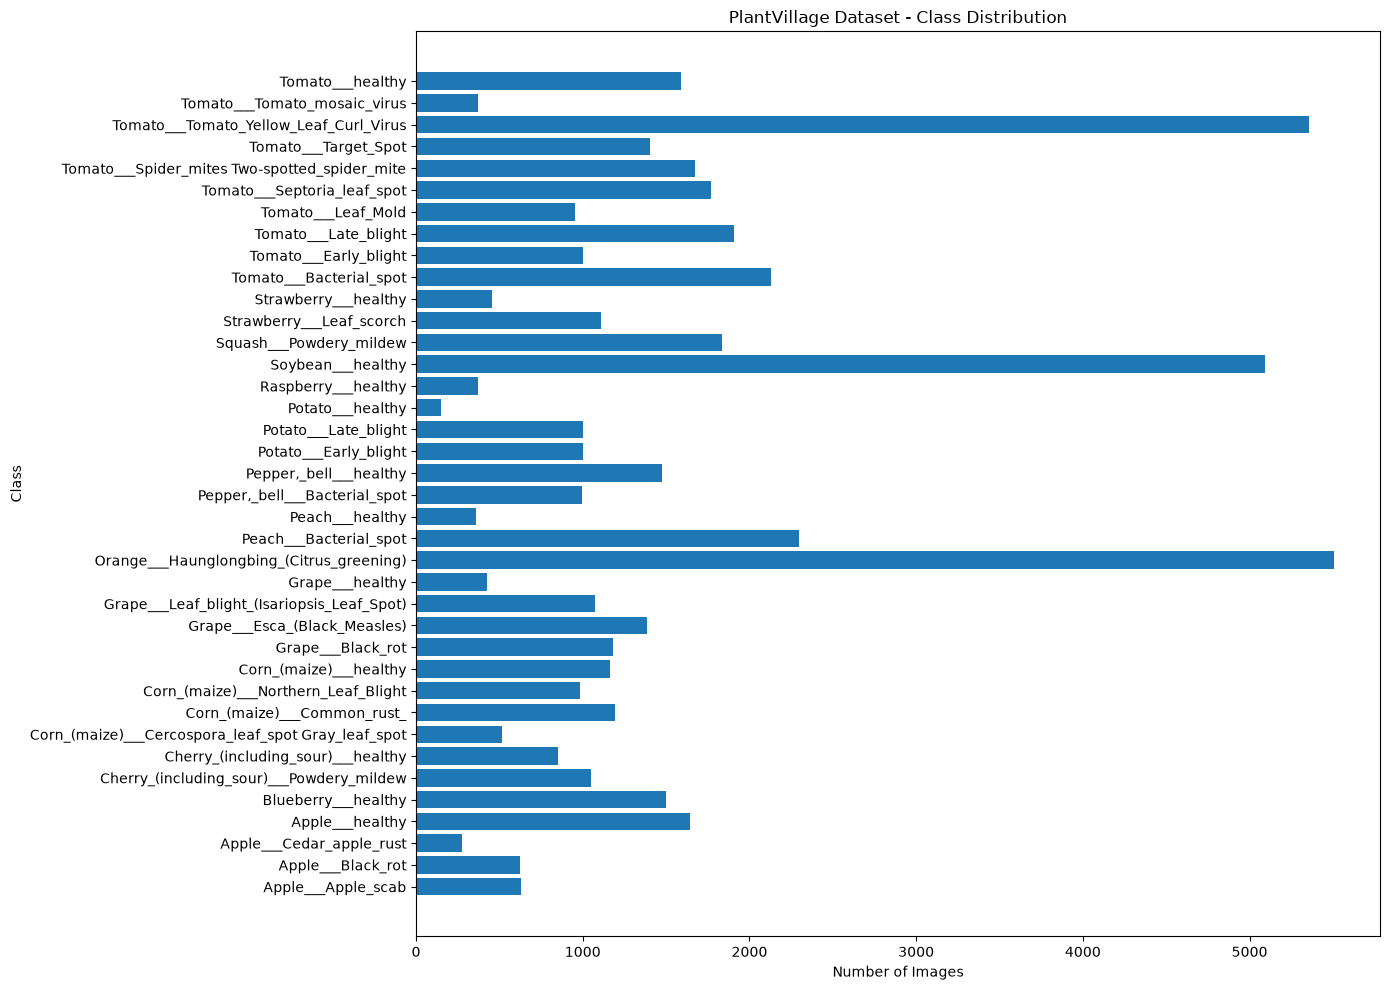

In [7]:
plt.figure(figsize=(14, 10))

plt.barh(
    distribution_df["class_name"],
    distribution_df["image_count"]
)

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("PlantVillage Dataset - Class Distribution")

plt.tight_layout()
plt.show()

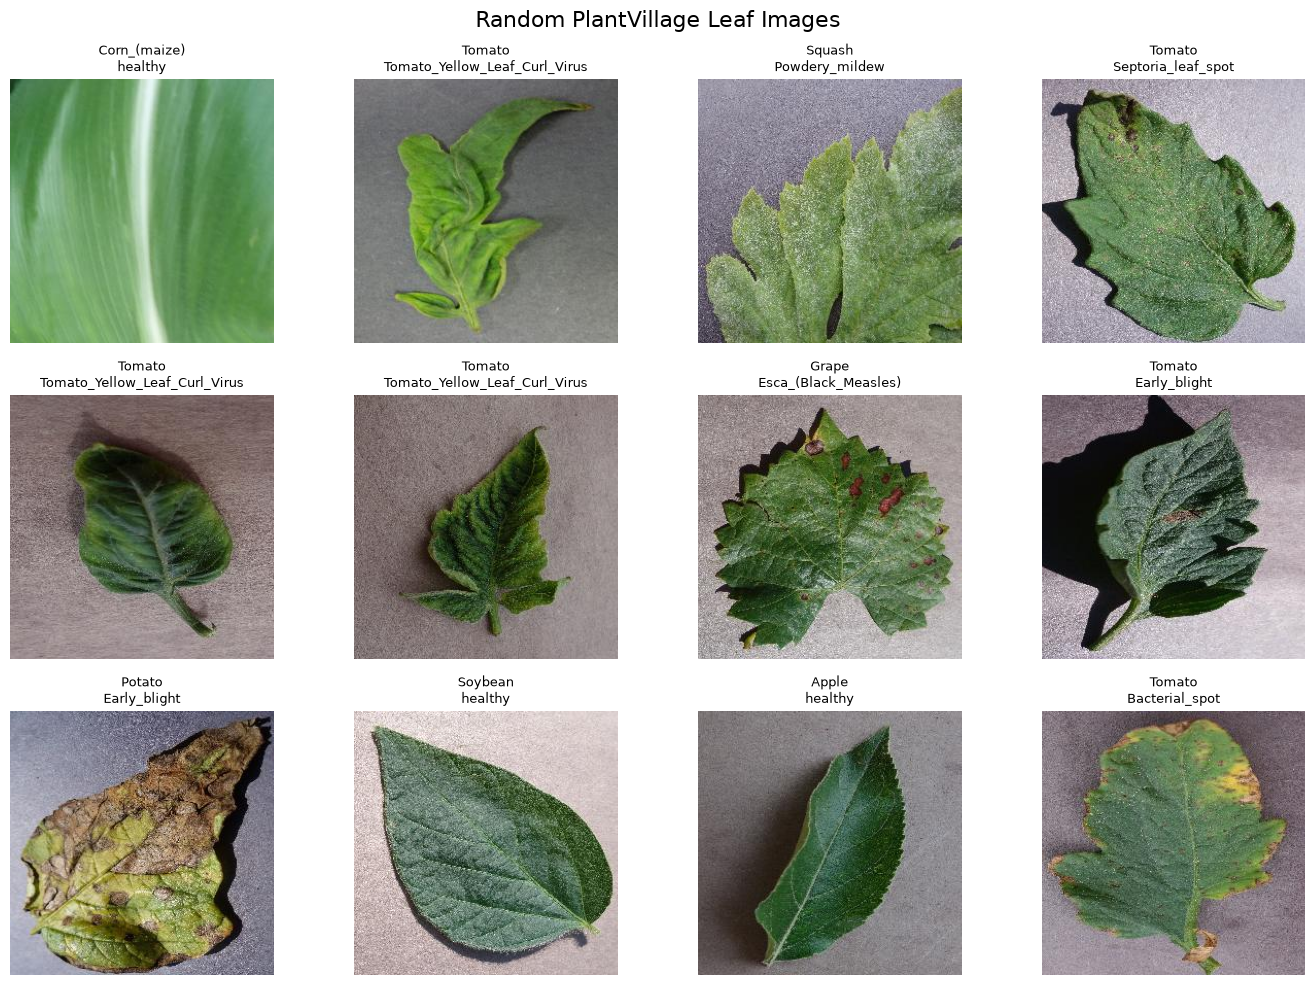

In [8]:
import random

# Select 12 random images
sample_df = df.sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    image = Image.open(row["image_path"])
    
    ax.imshow(image)
    ax.set_title(
        f'{row["crop"]}\n{row["disease"]}',
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Random PlantVillage Leaf Images", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
Why are we doing this?
We're checking:
Dataset
   ↓
Are images readable?
   ↓
Are labels correct?
   ↓
Do images contain leaves?
   ↓
What kind of backgrounds/lighting do we have?
   ↓
Then → train/validation/test split

In [9]:
from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

# Second split: divide the remaining 20% into
# 10% validation and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 43444
Validation images: 5430
Testing images: 5431


In [10]:
print("Unique classes in training:", train_df["label"].nunique())
print("Unique classes in validation:", val_df["label"].nunique())
print("Unique classes in testing:", test_df["label"].nunique())

Unique classes in training: 38
Unique classes in validation: 38
Unique classes in testing: 38


In [11]:
import os

SPLIT_DIR = r"C:\PlantVillage-Dataset\CropDiseaseAI\data\splits"

# Make sure the folder exists
os.makedirs(SPLIT_DIR, exist_ok=True)

# Save the three splits
train_df.to_csv(os.path.join(SPLIT_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(SPLIT_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(SPLIT_DIR, "test.csv"), index=False)

print("Dataset splits saved successfully!")
print("\nFiles created:")
print("1. train.csv")
print("2. val.csv")
print("3. test.csv")

Dataset splits saved successfully!

Files created:
1. train.csv
2. val.csv
3. test.csv


In [12]:
train_check = pd.read_csv(
    r"C:\PlantVillage-Dataset\CropDiseaseAI\data\splits\train.csv"
)

val_check = pd.read_csv(
    r"C:\PlantVillage-Dataset\CropDiseaseAI\data\splits\val.csv"
)

test_check = pd.read_csv(
    r"C:\PlantVillage-Dataset\CropDiseaseAI\data\splits\test.csv"
)

print("Train:", train_check.shape)
print("Validation:", val_check.shape)
print("Test:", test_check.shape)

print("\nColumns:")
print(train_check.columns.tolist())

Train: (43444, 4)
Validation: (5430, 4)
Test: (5431, 4)

Columns:
['image_path', 'crop', 'disease', 'label']
